Single Server Queue Simulation
Mean Interarrival Time = 2.0
Mean Service Time = 1.5
Number of Customers = 1000
Average Delay in Queue = 0.118
Average Number in Queue = 0.059
Server Utilization = 0.754
Time Simulation Ended = 2001.035


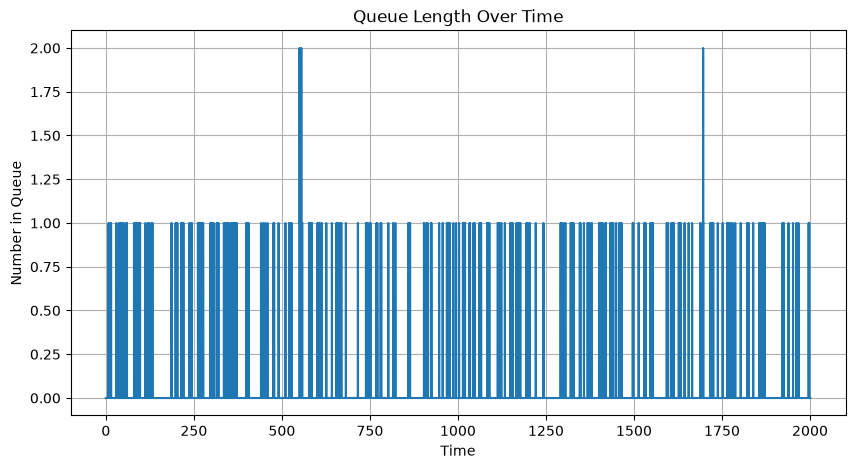

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
MEAN_INTERARRIVAL = 2.0
STD_INTERARRIVAL = 0.5

MEAN_SERVICE = 1.5
STD_SERVICE = 0.3

N_CUSTOMERS = 1000

clock = 0.0
server_busy = False
queue = []

area_Q = 0.0
area_B = 0.0
total_delay = 0.0

customers_departed = 0

# Normal distribution cannot generate negative times
next_arrival = max(
    0.01,
    np.random.normal(MEAN_INTERARRIVAL, STD_INTERARRIVAL)
)

next_departure = float("inf")

# For plotting
time_points = [0.0]
queue_lengths = [0]

while customers_departed < N_CUSTOMERS:

    next_event_time = min(next_arrival, next_departure)

    area_Q += len(queue) * (next_event_time - clock)
    area_B += (1 if server_busy else 0) * (next_event_time - clock)

    clock = next_event_time

    # -------- Arrival Event --------
    if next_arrival <= next_departure:

        if not server_busy:
            server_busy = True

            service_time = max(
                0.01,
                np.random.normal(MEAN_SERVICE, STD_SERVICE)
            )

            next_departure = clock + service_time

        else:
            queue.append(clock)

        next_arrival = clock + max(
            0.01,
            np.random.normal(MEAN_INTERARRIVAL, STD_INTERARRIVAL)
        )

    # -------- Departure Event --------
    else:

        customers_departed += 1

        if queue:

            arrival_time = queue.pop(0)

            delay = clock - arrival_time
            total_delay += delay

            service_time = max(
                0.01,
                np.random.normal(MEAN_SERVICE, STD_SERVICE)
            )

            next_departure = clock + service_time

        else:
            server_busy = False
            next_departure = float("inf")

    # Store values for graph
    time_points.append(clock)
    queue_lengths.append(len(queue))

# Performance Measures
avg_delay = total_delay / N_CUSTOMERS
avg_queue = area_Q / clock
utilization = area_B / clock
end_time = clock

print("Single Server Queue Simulation")
print("Mean Interarrival Time =", MEAN_INTERARRIVAL)
print("Mean Service Time =", MEAN_SERVICE)
print("Number of Customers =", N_CUSTOMERS)
print("Average Delay in Queue =", round(avg_delay, 3))
print("Average Number in Queue =", round(avg_queue, 3))
print("Server Utilization =", round(utilization, 3))
print("Time Simulation Ended =", round(end_time, 3))

# Plot Queue Length
plt.figure(figsize=(10,5))
plt.step(time_points, queue_lengths, where="post")
plt.xlabel("Time")
plt.ylabel("Number in Queue")
plt.title("Queue Length Over Time")
plt.grid(True)
plt.show()